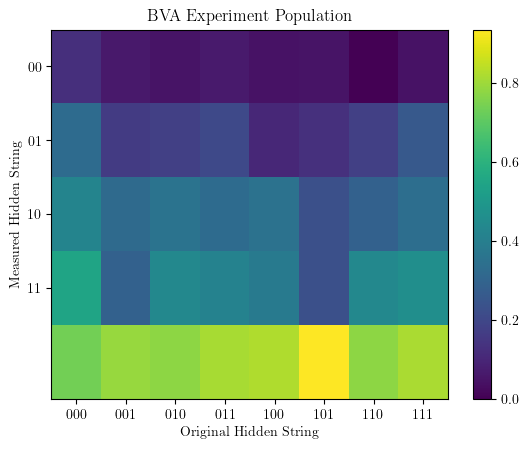

List of file paths (last line in each file):
000: Z:\Lab Data\Algorithms\Polyqubit_BVA\IonControl_raw_data_copied\2026\2026_03\2026_03_06\BVA_2_polyqubit_012
001: Z:\Lab Data\Algorithms\Polyqubit_BVA\IonControl_raw_data_copied\2026\2026_03\2026_03_06\BVA_2_polyqubit_013
010: Z:\Lab Data\Algorithms\Polyqubit_BVA\IonControl_raw_data_copied\2026\2026_03\2026_03_06\BVA_2_polyqubit_014
011: Z:\Lab Data\Algorithms\Polyqubit_BVA\IonControl_raw_data_copied\2026\2026_03\2026_03_06\BVA_2_polyqubit_015
100: Z:\Lab Data\Algorithms\Polyqubit_BVA\IonControl_raw_data_copied\2026\2026_03\2026_03_06\BVA_2_polyqubit_016
101: Z:\Lab Data\Algorithms\Polyqubit_BVA\IonControl_raw_data_copied\2026\2026_03\2026_03_06\BVA_2_polyqubit_017
110: Z:\Lab Data\Algorithms\Polyqubit_BVA\IonControl_raw_data_copied\2026\2026_03\2026_03_06\BVA_2_polyqubit_018
111: Z:\Lab Data\Algorithms\Polyqubit_BVA\IonControl_raw_data_copied\2026\2026_03\2026_03_06\BVA_2_polyqubit_019


In [6]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

def parse_population_line(line):
    """
    Parse a line like:
      [0.         1.         0.84848485 0.77777778 0.66666667]
    into a numpy array.
    """
    line = line.strip()
    # Remove surrounding brackets if present
    if line.startswith('[') and line.endswith(']'):
        line = line[1:-1]
    # Use numpy.fromstring to read numbers separated by whitespace.
    values = np.fromstring(line, sep=' ')
    return values

# Change the pattern/path as needed.
# For example, if your files are in the current directory:
# file_pattern = "Z:\\Lab Data\\Algorithms\\Polyqubit_BVA\\BVA_logs\\BVA_2_polyqubit_hiddenstring_*_20250501_1326*"
file_pattern = "Z:\\Lab Data\\Algorithms\\Polyqubit_BVA\\BVA_logs\\BVA_3_polyqubit_hiddenstring_*_20250430_1653*"
# file_pattern = "Z:\\Lab Data\\Algorithms\\Polyqubit_BVA\\BVA_logs\\BVA_3_polyqubit_hiddenstring_*_20250514_1351*"
# file_pattern = "Z:\\Lab Data\\Algorithms\\Polyqubit_BVA\\BVA_logs\\BVA_3_polyqubit_hiddenstring_*_20250514_1429*"

# file_pattern = "Z:\\Lab Data\\Algorithms\\Polyqubit_BVA\\BVA_logs\\BVA_3_polyqubit_hiddenstring_*_20250514_1443*"
# file_pattern = "Z:\\Lab Data\\Algorithms\\Polyqubit_BVA\\BVA_logs\\BVA_3_polyqubit_hiddenstring_*_20250516_1544*"

file_pattern = "Z:\\Lab Data\\Algorithms\\Polyqubit_BVA\\RFSoC_BVA_logs\\BVA_3_polyqubit_hiddenstring_*_20260306_1904*"

files = glob.glob(file_pattern)

if not files:
    print("No files found with the pattern:", file_pattern)
    exit()

# Dictionary to store the population vector and file path keyed by original hidden string.
pop_data = {}
file_paths = {}

for filename in files:
    # Example filename: BVA_2_polyqubit_hiddenstring_00_20250324_1855
    base = os.path.basename(filename)
    parts = base.split('_')
    # Assuming the original hidden string is the part right after "hiddenstring"
    # e.g., parts = ["BVA", "2", "polyqubit", "hiddenstring", "00", "20250324", "1855"]
    try:
        idx = parts.index("hiddenstring")
        original_hidden = parts[idx + 1]
    except ValueError:
        print("Filename does not match expected pattern:", filename)
        continue

    # Read file lines
    with open(filename, 'r') as f:
        lines = f.readlines()

    if len(lines) < 2:
        print("File", filename, "does not have enough lines.")
        continue

    # The first line is the population vector.
    pop_vector = parse_population_line(lines[0])
    # The last line is assumed to be the file path.
    file_path_line = lines[-1].strip()

    pop_data[original_hidden] = pop_vector
    file_paths[original_hidden] = file_path_line

# Sort the data based on the original hidden string.
# We assume the hidden strings are binary numbers (e.g., '00', '01', '10', '11').
sorted_keys = sorted(pop_data.keys(), key=lambda x: int(x, 2))

# Build the matrix where each column is the population vector for an original hidden string.
# Each vector is assumed to contain 5 numbers: [bus, |00>, |01>, |10>, |11>]
matrix = np.column_stack([pop_data[k] for k in sorted_keys])

# Create an imshow plot
plt.figure()
im = plt.imshow(matrix, aspect='auto', interpolation='none')
plt.colorbar(im)
plt.xticks(ticks=np.arange(len(sorted_keys)), labels=sorted_keys)
# Define y-axis labels: first entry is the bus state, followed by the two-qubit states.
measured_labels = ['00', '01', '10', '11']
# measured_labels = ['000', '001', '010', '011', '100', '101', '110', '111']
plt.yticks(ticks=np.arange(len(measured_labels)), labels=measured_labels)
plt.xlabel('Original Hidden String')
plt.ylabel('Measured Hidden String')
plt.title('BVA Experiment Population')
plt.show()

# Print the list of file paths corresponding to each original hidden string
print("List of file paths (last line in each file):")
for key in sorted_keys:
    print(f"{key}: {file_paths[key]}")


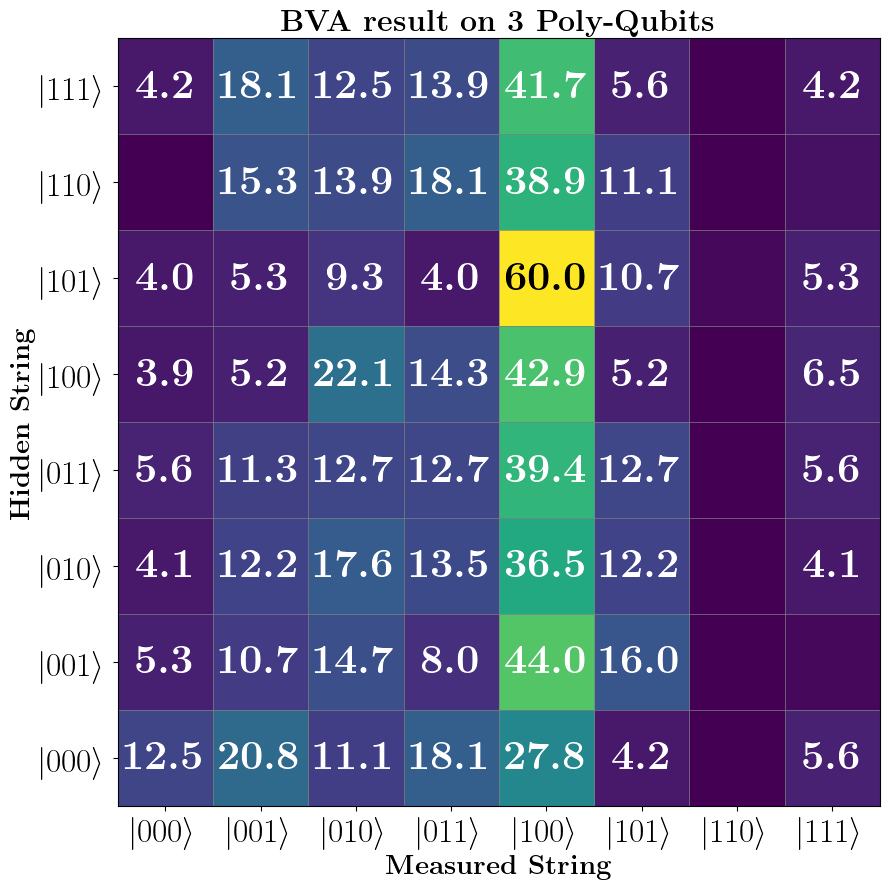

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import json

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

def load_experiment_from_file(path):
    exp = []
    with open(path, 'r') as f:
        for ln in f:
            exp.append(json.loads(ln)[0]["0"])
    return exp

def getShelvingThreshold(counts):
    ds = np.sort(counts, axis=None)
    if len(ds) > 4000:
        ds = ds[2000:]
    if len(ds) > 2000:
        st = round(ds.size / (len(counts) * 0.00150167))
        st = 1 if st < 1 else st
        ds = ds[0:-1:st]
    dsd = ds[1:-1] - ds[0:-2]
    th = max(dsd) / 2 + ds[np.argmax(dsd)]
    hc, be = np.histogram(counts, bins=range(4, 31))
    th = be[np.argmin(hc)] + 0.5
    return th, ds

keys = list(file_paths.keys())
n_kets = len(keys)
ket_avg = [None] * n_kets
ket_dr  = [0]    * n_kets
thr_inf = [None] * n_kets

for i, k in enumerate(keys):
    exps = load_experiment_from_file(file_paths[k])
    if len(exps) == 0:
        continue
    exps = np.array(exps)
    flat = exps.ravel()
    try:
        th, _ = getShelvingThreshold(flat)
    except:
        th = None
    thr_inf[i] = (flat, th, k)
    bm = exps > th
    res = np.full(bm.shape, False, dtype=bool)
    for r in range(bm.shape[0]):
        ti = np.where(bm[r])[0]
        if ti.size > 0 and ti[0] != 0:
            res[r, ti[0]] = True
    vr = res.any(axis=1)
    filt = res[vr]
    ket_dr[i] = filt.shape[0] / exps.shape[0]
    if filt.shape[0] > 0:
        ket_avg[i] = np.mean(filt, axis=0)

meas_dim = next((len(v) - 1 for v in ket_avg if v is not None and len(v) > 1), n_kets)
data_m = np.zeros((n_kets, meas_dim))
for i in range(n_kets):
    if ket_avg[i] is not None and len(ket_avg[i]) > 1:
        vec = ket_avg[i][1:]
        data_m[i, :len(vec)] = vec[:meas_dim]

fid = [data_m[i, i] if i < meas_dim else data_m[i, -1] for i in range(n_kets) if ket_avg[i] is not None]
dr  = [ket_dr[i] for i in range(n_kets) if ket_dr[i] > 0]
avg_fid = np.mean(fid) if fid else np.nan
avg_dr  = np.mean(dr)  if dr  else np.nan

fig, ax = plt.subplots(figsize=(9, 9))
cmap = plt.get_cmap("viridis")
im = ax.imshow(data_m, cmap=cmap, aspect='auto')
tick_lbls = [f'$|{k}\\rangle$' for k in keys]
measured_keys = ['000', '001', '010', '011', '100', '101', '110', '111']
# measured_keys = ['00', '01', '10', '11']
meas_lbls = [f'$|{k}\\rangle$' for k in measured_keys]
ax.set_xticks(np.arange(meas_dim))
ax.set_xticklabels(meas_lbls, fontsize=24)
ax.set_yticks(np.arange(n_kets))
ax.set_yticklabels(tick_lbls, fontsize=24)
ax.invert_yaxis()
ax.set_xlabel(r'\textbf{Measured String}', fontsize=20)
ax.set_ylabel(r'\textbf{Hidden String}', fontsize=20)

for i in range(n_kets):
    if ket_avg[i] is None:
        ax.text(meas_dim/2, i, r'\textbf{No Valid Data}', ha='center', va='center', color='red', fontsize=14)
    else:
        for j in range(meas_dim):
            if data_m[i, j] > 0.035:
                ax.text(j, i, rf'\textbf{{{data_m[i, j]*100:.1f}}}', ha='center', va='center',
                        color='black' if data_m[i, j] > 0.5 else 'white', fontsize=30)

for x in np.arange(-0.5, meas_dim, 1):
    ax.axvline(x, color='gray', linewidth=0.5)
for y in np.arange(-0.5, n_kets, 1):
    ax.axhline(y, color='gray', linewidth=0.5)

ax.set_title(r'\textbf{BVA result on 3 Poly-Qubits}', fontsize=22)
plt.tight_layout()
plt.savefig('3_poly_qubit_BVA.svg')
plt.show()


In [10]:
import numpy as np
#=====================HELPER_FUNCTIONS=============================
def fix_couplings_and_phases(couplings, fixed_phase_flags, Virtual_Z=False, Z_gate_states=None):
    new_couplings = []
    new_fixed_phase_flags = []
    for (cpl, phase_flag) in zip(couplings, fixed_phase_flags):
        i, j = cpl
        if i != 0 and j == 0:
            cpl_fixed = (0, i)
            phase_flag_fixed = phase_flag + 1.0
        else:
            cpl_fixed = cpl
            phase_flag_fixed = phase_flag

        if Virtual_Z and Z_gate_states is not None:
            if i in Z_gate_states or j in Z_gate_states:
                phase_flag_fixed += 1.0
        new_couplings.append(cpl_fixed)
        new_fixed_phase_flags.append(phase_flag_fixed)
    return new_couplings, new_fixed_phase_flags


def parse_string_to_int_list(s):
    s = s.strip()
    if s.startswith('[') and s.endswith(']'):
        inside = s[1:-1].strip()
        parts = inside.split(',')
        return [int(x) for x in parts]
    else:
        return [int(s)]

def build_transitions_list(index_to_str_map, couplings):
    transitions_list = []
    for (start_idx, end_idx) in couplings:
        left_list  = parse_string_to_int_list(index_to_str_map[start_idx])
        right_list = parse_string_to_int_list(index_to_str_map[end_idx])
        transitions_list.append(left_list + right_list)
    return transitions_list

transition_strengths = np.loadtxt(
    'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\Transition_strengths_4p209.txt', delimiter=','
)

def compute_pi_times(pi_t, ref_transitions = np.array([
        transition_strengths[23, 0], transition_strengths[14, 0],
        transition_strengths[17, 4], transition_strengths[16, 4], transition_strengths[15, 4]
    ])):
    transition_strengths = np.loadtxt(
        'Z:\\Lab Data\\Phase_and_freq_correction_180Hz\\Transition_strengths_4p209.txt', delimiter=','
    )
    transition_strengths[transition_strengths == 0] = np.nan

    # pi_t = np.array([19.470, 35.554, 41.166, 30.108, 39.326])
    strengths = ref_transitions

    factors = np.array(pi_t) * strengths
    Fs = [1, 2, 3, 4]
    row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
    col_labels = [-2, -1, 0, 1, 2]

    pi_times = np.zeros((24, 5))
    for i in range(np.shape(transition_strengths)[0]):
        for j in range(np.shape(transition_strengths)[1]):
            if not np.isnan(transition_strengths[i, j]):
                delta_m = (row_labels[i][1] - col_labels[j]) + 2
                pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
    
    return pi_times

def get_pi_times(transitions, pi_t,ref_transitions = np.array([
        transition_strengths[21, 2], transition_strengths[14, 0],
        transition_strengths[5, 2], transition_strengths[16, 4], transition_strengths[15, 4]
    ])):
    matrix = compute_pi_times(pi_t, ref_transitions)
    pi_times_list = []
    col_labels = [-2, -1, 0, 1, 2]
    for transition in transitions:
        if transition[1] == 0 and transition[2] == 0:
            pi_times_list.append(1e6)
            continue
        row_label = [transition[1],transition[2]]
        Fs = [1,2,3,4]
        states = []
        for i in Fs:
            for j in range(2*i+1):
                mF = i-j
                states.append([i,mF])
    
        row_labels = states
    
        col_label = transition[0]
    
        # Find the index of the row label
        row_index = next((i for i, label in enumerate(row_labels) if label == row_label), None)
        # Find the index of the column label
        col_index = col_labels.index(col_label)
        
        if row_index is not None and col_index in range(len(col_labels)):
            pi_times_list.append(matrix[row_index, col_index])
        else:
            pi_times_list.append(1e6)

    return pi_times_list

def pulse_duration_for_fraction(f, pi_times):
    Omega = np.pi/np.array(pi_times)
    # if not (0 <= f <= 1):
    #     raise ValueError("Fraction f must be between 0 and 1.")
    theta = np.pi*f # 2.0 * np.arcsin(np.sqrt(f))
    return theta / Omega 

#=====================GATE_FUNCTIONS=============================

def Bussed_PolyQubit_Hadamard(dim, mappings,pi_t = [14.2,19.14,49.87,15.6,20.031], U1 = False, Virtual_Z = False, Z_gate_state = None):
    if dim == 2:
        # couplings = [(2,0),(0,1),(2,0)] + [(4,0),(3,0)]  + [(0,1),(3,0)] + [(0,2),(4,0)] 
        # theta = [1,1/2,1] + [1,1/2]  + [1/2,1] + [1/2,1]      
        # fixed_phase_flags = [0.5,0.5,0.5] + [0.5,0.5]  + [0.5,0.5] + [0.5,0.5]
        #couplings = [(0, 2), (3, 0), (0, 1), (4, 0), (0, 1), (3, 0), (2, 0)]
        #theta = [1, 0.5, 2.0 * np.arcsin(np.sqrt(1/3))/np.pi, 2/3, 2.0 * np.arcsin(np.sqrt(1/3))/np.pi, 0.5, 1]
        #fixed_phase_flags = [1,0,0,0,0,0,0,0]
        
        couplings = [(0, 3), (0, 1), (0, 2), (0, 1), (0, 3)]
        theta = [0.5, 2.0 * np.arcsin(np.sqrt(1/3))/np.pi, 4/3, 2.0 * np.arcsin(np.sqrt(2/3))/np.pi + 1, 0.5]
        fixed_phase_flags = [1.5, 0.5, 1.5, 0.5, 0.5]
        couplings, fixed_phase_flags = fix_couplings_and_phases(couplings, fixed_phase_flags,Virtual_Z = Virtual_Z, Z_gate_states = Z_gate_state)
        probe_couplings = [(0,1),(0,2),(0,3)]
    if dim == 3:
        if U1:
            couplings = [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7)]
            theta = [2*np.arcsin(np.sqrt(1/8))/np.pi, 2*np.arcsin(np.sqrt(1/7))/np.pi, 2*np.arcsin(np.sqrt(1/6))/np.pi, 2*np.arcsin(np.sqrt(1/5))/np.pi, 2*np.arcsin(np.sqrt(1/4))/np.pi, 2*np.arcsin(np.sqrt(1/3))/np.pi, 2*np.arcsin(np.sqrt(1/2))/np.pi+1]
            fixed_phase_flags = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
            
        else:
            couplings =  [(0, 6), (0, 1), (0, 3), (0, 5), (0, 4), (0, 2), (0, 4), (0, 5), (0, 7), (0, 3), (0, 1), (0, 2), (0, 4), (0, 7), (0, 1), (0, 5), (0, 3), (0, 6), (0, 7), (0, 1), (0, 6)]
            theta =  [1.5, 1, 1., 1.5, 2.0 * np.arcsin(np.sqrt(1/3))/np.pi, 2/3, 1 + 2.0 * np.arcsin(np.sqrt(1/3))/np.pi, 1, 1, 0.5, 0.5, 0.5, 1.0, 1.5, 1.0, 1.5, 1, 1.5, 1.5, 1, 1.5]
            fixed_phase_flags =  [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.5, 1.5, 0.5, 0.5, 0.5, 1.5, 0.5, 0.5, 1.5, 1.5, 0.5, 1.5, 1.5]
    
        #couplings = [(2,0),(0,1),(2,0)] + [(4,0),(3,0)]  + [(0,1),(3,0)] + [(0,2),(4,0)]\
        #          + [(6,0),(0,5),(6,0)] + [(8,0),(7,0)]  + [(0,5),(7,0)] + [(6,0)]\
        #          + [(0,2),(6,0)] + [(5,0),(0,1),(5,0)] + [(7,0),(0,3),(7,0)] + [(0,4),(8,0)]
        #theta = [1,1/2,1] + [1,1/2]  + [1/2,1] + [1/2,1]\
        #          + [1,1/2,1] + [1,1/2]  + [1/2,1] + [1/2]\
        #          + [1/2,1] + [1,1/2,1] + [1,1/2,1] + [1/2,1]
        #fixed_phase_flags = [0.5,0.5,0.5] + [0.5,0.5]  + [0.5,0.5] + [0.5,0.5]\
        #                   +[0.5,0.5,0.5] + [0.5,0.5]  + [0.5,0.5] + [0.5]\
        #                   + [0.5,0.5] + [0.5,0.5,0.5] + [0.5,0.5,0.5] + [0.5,0.5]
        couplings, fixed_phase_flags = fix_couplings_and_phases(couplings, fixed_phase_flags,Virtual_Z = Virtual_Z, Z_gate_states = Z_gate_state)
        probe_couplings = [(0,1),(0,2),(0,3),(0,4),(0,5),(0,6),(0,7)]
    Hadamard_trans = build_transitions_list(mappings,couplings)
    Hadamard_pitimes = list(pulse_duration_for_fraction(np.array(theta),get_pi_times(Hadamard_trans,compute_pi_times(pi_t))))
    probe_trans = build_transitions_list(mappings,probe_couplings)
    return Hadamard_trans, Hadamard_pitimes,fixed_phase_flags, theta, probe_trans

def PolyQubit_Toffoli(dim, mappings,pi_t = [23.172,40.114,47.954,34.418,46.591]):
    if dim == 4:
        couplings = [(0,1)]
        theta =  [1]
        fixed_phase_flags =  [0]
        couplings, fixed_phase_flags = fix_couplings_and_phases(couplings, fixed_phase_flags,Virtual_Z = False, Z_gate_states = None)
        probe_couplings = [(0,1),(0,2),(0,3),(0,4),(0,5),(0,6),(0,7),(0,8),(0,9),(0,10),(0,11),(0,12),(0,13),(0,14),(0,15)]
    trans = build_transitions_list(mappings,couplings)
    pitimes = list(pulse_duration_for_fraction(np.array(theta),get_pi_times(trans,compute_pi_times(pi_t))))
    probe_trans = build_transitions_list(mappings,probe_couplings)
    return trans, pitimes,fixed_phase_flags, theta, probe_trans

# if __name__ == "__main__":

#mappings = {0: '-2', 1: '[2, -1]', 2: '[3, -2]', 3: '[4, -4]', 4: '[3, -3]'}
#mappings = {0: '1', 1: '[2, -1]', 2: '[3, 2]', 3: '[4, 2]', 4: '[4, 0]', 5: '[3, 3]', 6: '[4, 1]', 7: '[4, -1]'}
mappings = {0: '0', 1: '[3, -2]', 2: '[4, -1]', 3: '[3, 1]', 4: '[4, 1]', 5: '[3, 0]', 6: '[4, 1]', 7: '[3, -1]'}

# mappings = {
#     0: '0', 1: '[4, -2]', 2: '[3, 1]', 3: '[4, -1]', 
#     4: '[3, 0]', 5: '[3, 2]', 6: '[4, 0]', 7: '[2, -2]', 
#     8: '[2, 0]', 9: '[2, 2]', 10: '[4, 1]', 11: '[3, -1]', 
#     12: '[1, 1]', 13: '[2, -1]', 14: '[1, -1]', 15: '[2, 1]'}
print(Bussed_PolyQubit_Hadamard(2,mappings))
    

ValueError: setting an array element with a sequence.

In [12]:
Hadamard_trans = [[0, 4, -2]]
pi_t = [14.2,19.14,49.87,15.6,20.031]
get_pi_times(Hadamard_trans,pi_t)



[np.float64(14.2)]